In [ ]:
#get data
# downloaded July 9, 2026
# https://cellxgene.cziscience.com/collections/edb893ee-4066-4128-9aec-5eb2b03f8287
# core atlas
# core NSCLC atlas scRNA-seq data from 19 studies and 21 datasets comprising 505 samples from 298 patients

In [ ]:
from pathlib import Path
import os

print("Current directory:")
print(Path.cwd())

# or
os.getcwd()

In [ ]:
# from pathlib import Path
# import subprocess
# import sys
# 
# DATA_DIR = Path("data/nsclc")
# DATA_DIR.mkdir(parents=True, exist_ok=True)
# 
# url = "https://datasets.cellxgene.cziscience.com/46e0287b-9a33-4e83-99f3-8c044131bfdc.h5ad"
# outfile = DATA_DIR / "nsclc_integrated.h5ad"
# 
# # Running with stdout directly bound allows you to see the actual wget progress bar
# process = subprocess.run(
#     ["wget", "-O", str(outfile), url],
#     stdout=sys.stdout,
#     stderr=sys.stderr
# )
# 
# if process.returncode == 0:
#     print("Downloaded successfully to:", outfile)
# else:
#     print("Download failed with return code:", process.returncode)

In [ ]:
from pathlib import Path
import subprocess
import sys
import scanpy as sc

# Keep Scanpy plots compact for notebook viewing
sc.settings.set_figure_params(dpi=100, dpi_save=100)
import pandas as pd

# =====================================================================
# 1. SETUP SEPARATE DIRECTORY STRUCTURE
# =====================================================================
ALLOGRAFT_DIR = Path("data/lung_allograft")
ALLOGRAFT_DIR.mkdir(parents=True, exist_ok=True)

url = "https://datasets.cellxgene.cziscience.com/af6e81be-e65c-4821-987e-e0eb6c8acd59.h5ad"
outfile = ALLOGRAFT_DIR / "lung_allograft_biopsy.h5ad"


In [ ]:

# =====================================================================
# 2. RUN DOWNLOAD WITH REAL-TIME PROGRESS FEEDBACK
# =====================================================================
# 2. Download with explicit text progress updates (Every 50MB)
if not outfile.exists():
    print(f"Starting download to: {outfile}")
    
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    total_bytes = int(response.headers.get('content-length', 0))
    total_mb = total_bytes / (1024 * 1024)
    
    downloaded_bytes = 0
    last_reported_mb = 0
    
    with open(outfile, "wb") as f:
        # Read file in small 1MB chunks
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded_bytes += len(chunk)
                
                current_mb = downloaded_bytes / (1024 * 1024)
                
                # Print an explicit update line every 50 Megabytes downloaded
                if current_mb - last_reported_mb >= 50:
                    print(f" -> Progress: {current_mb:.0f}MB / {total_mb:.0f}MB downloaded...")
                    last_reported_mb = current_mb
                    
    print("\n[SUCCESS] Download completed 100%!")
else:
    print(f"File already exists at {outfile}. No download needed!")

In [ ]:

# =====================================================================
# 3. HARMONIZE AND APPLY STRICT CATEGORY FILTERING (ALL NICHE >= 1000)
# =====================================================================
print("\nLoading dataset metadata blocks via Backed Mode...")
adata_cancer = sc.read_h5ad("data/nsclc/nsclc_integrated.h5ad", backed="r")
adata_allograft = sc.read_h5ad(str(outfile), backed="r")

# Generate standard cross-tabulation tables
ct_cancer = pd.crosstab(adata_cancer.obs['cell_type_major'], adata_cancer.obs['disease'])
ct_allograft = pd.crosstab(adata_allograft.obs['cell_type'], adata_allograft.obs['disease'])

# Apply cross-category filtering rule
valid_cancer_lineages = ct_cancer[(ct_cancer >= 1000).all(axis=1)].index
valid_allograft_lineages = ct_allograft[(ct_allograft >= 1000).all(axis=1)].index

# Intersect the datasets to see what shared lineages are safe for comparison
shared_robust_lineages = valid_cancer_lineages.intersection(valid_allograft_lineages)

# Save cross-tabulation summaries as separate structural files inside the new folder
ct_cancer.loc[valid_cancer_lineages].to_csv(ALLOGRAFT_DIR / "filtered_cancer_counts.csv")
ct_allograft.loc[valid_allograft_lineages].to_csv(ALLOGRAFT_DIR / "filtered_allograft_counts.csv")

print(f"\n--- Matrix Sync Complete ---")
print(f"Outputs written to directory: '{ALLOGRAFT_DIR}/'")
print(f"Shared robust cell states identified: {list(shared_robust_lineages)}")

In [ ]:
# Let's preview the first few rows of metadata to confirm the naming convention
print(adata_allograft.obs.head())

In [ ]:
import scanpy as sc
import pandas as pd

# 1. Open in "backed" mode - this reads 0 cells into memory, only index metadata
adata_backed = adata_cancer

print("Total matrix footprint:", adata_backed.shape)

# 2. Inspect the observation (metadata) columns to match your text labels
# Usually look for columns like 'patient_id', 'cell_type', 'disease', or 'tissue'
print("\nMetadata columns available (.obs):")
print(list(adata_backed.obs.columns))

# Let's preview the first few rows of metadata to confirm the naming convention
print(adata_backed.obs.head())

In [ ]:
# Extract value counts directly from the metadata dataframe
cell_type_counts = adata_backed.obs['cell_type_major'].value_counts()

print("--- Major Cell Type Breakdowns ---")
print(cell_type_counts)

In [ ]:
# Create a breakdown matrix showing cell types vs disease states
cell_disease_matrix = pd.crosstab(
    adata_backed.obs['cell_type_major'], 
    adata_backed.obs['disease']
)

print("--- Cell Type Distribution across Disease States ---")
print(cell_disease_matrix)

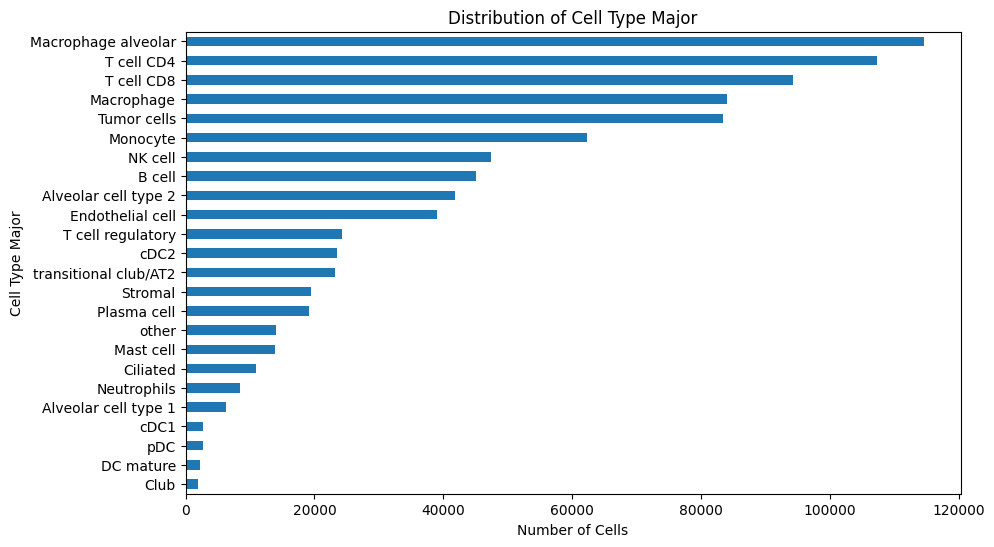

In [ ]:
import matplotlib.pyplot as plt

# Screen-friendly figures for notebooks and Git review
LOW_RES_DPI = 100
plt.rcParams.update({
    "figure.dpi": LOW_RES_DPI,
    "savefig.dpi": LOW_RES_DPI,
})

# Plotting directly from the pandas Series means 0 extra memory pressure
adata_backed.obs['cell_type_major'].value_counts().plot(kind='barh', figsize=(10, 6))
plt.title("Distribution of Cell Type Major")
plt.xlabel("Number of Cells")
plt.ylabel("Cell Type Major")
plt.gca().invert_yaxis() # Puts the highest count at the top
plt.show()

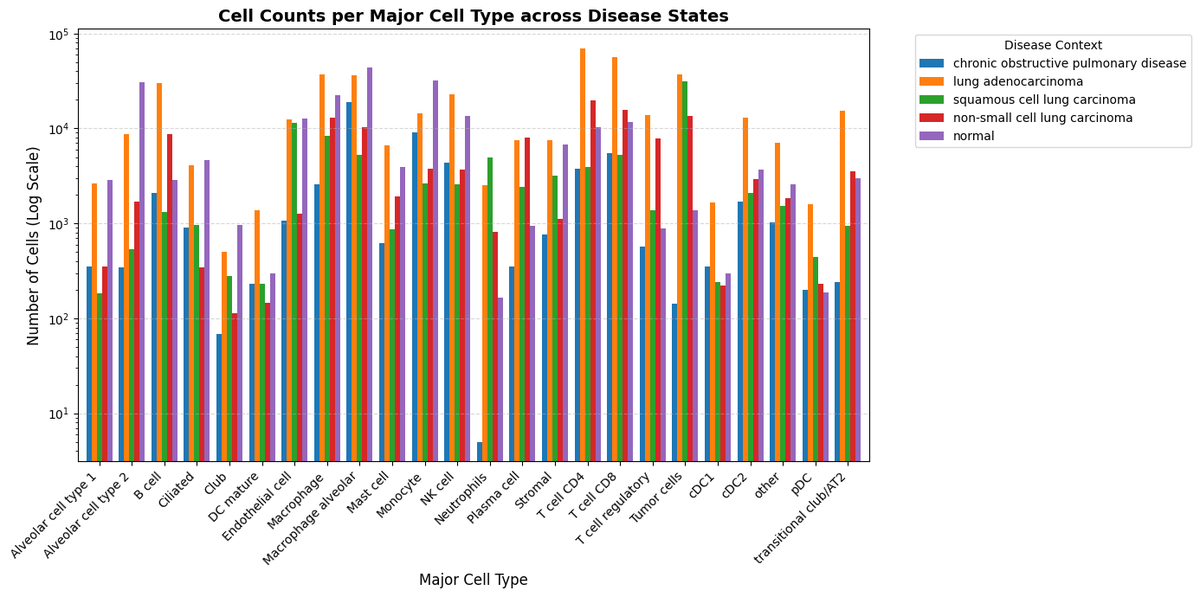

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute the cross-tabulation table (Cell Types vs Disease)
# Since adata_backed.obs is a normal pandas DataFrame, this reads no matrix data into RAM
ct_disease_counts = pd.crosstab(
    adata_backed.obs['cell_type_major'], 
    adata_backed.obs['disease']
)

# 2. Plotting a Grouped Bar Chart to inspect balancing
plt.figure(figsize=(14, 8))
# We use a log scale because cell counts can span from hundreds to hundreds of thousands
# This makes it much easier to find "balanced" combinations visually across extreme ranges
ct_disease_counts.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title("Cell Counts per Major Cell Type across Disease States", fontsize=14, fontweight='bold')
plt.xlabel("Major Cell Type", fontsize=12)
plt.ylabel("Number of Cells (Log Scale)", fontsize=12)
plt.yscale('log')  # Switch to log scale to catch proportions across different orders of magnitude
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Disease Context", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


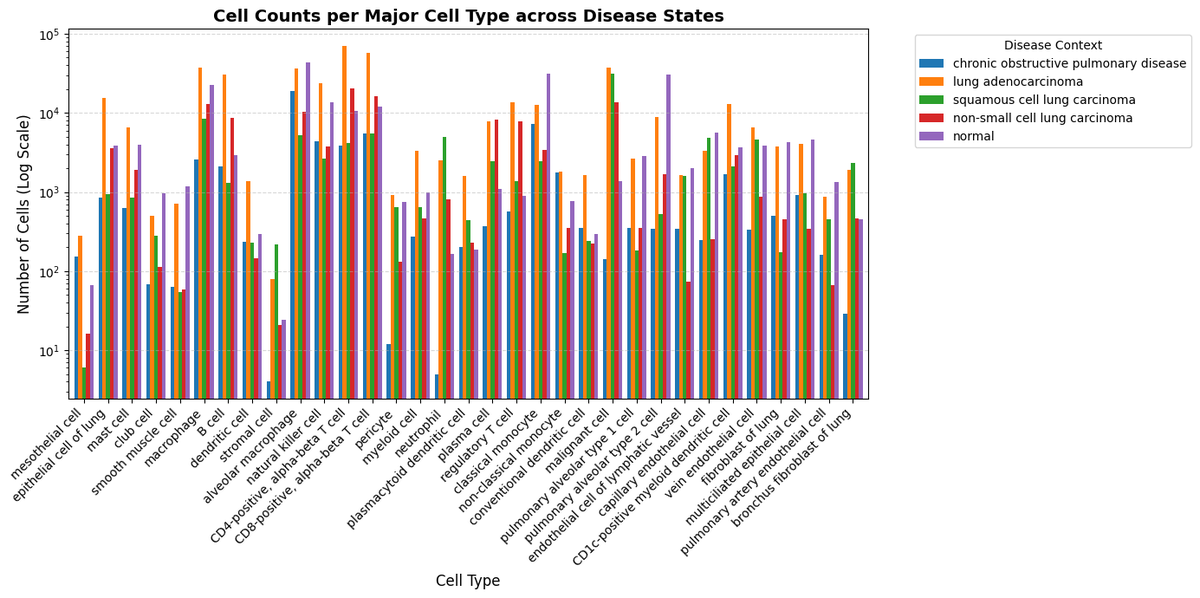

In [ ]:
# 2. Compute the cross-tabulation table (Cell Type vs Disease)
# Since adata_backed.obs is a normal pandas DataFrame, this reads no matrix data into RAM
ct_disease_counts = pd.crosstab(
    adata_backed.obs['cell_type'], 
    adata_backed.obs['disease']
)

# 2. Plotting a Grouped Bar Chart to inspect balancing
plt.figure(figsize=(14, 8))
# We use a log scale because cell counts can span from hundreds to hundreds of thousands
# This makes it much easier to find "balanced" combinations visually across extreme ranges
ct_disease_counts.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title("Cell Counts per Major Cell Type across Disease States", fontsize=14, fontweight='bold')
plt.xlabel("Cell Type", fontsize=12)
plt.ylabel("Number of Cells (Log Scale)", fontsize=12)
plt.yscale('log')  # Switch to log scale to catch proportions across different orders of magnitude
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Disease Context", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

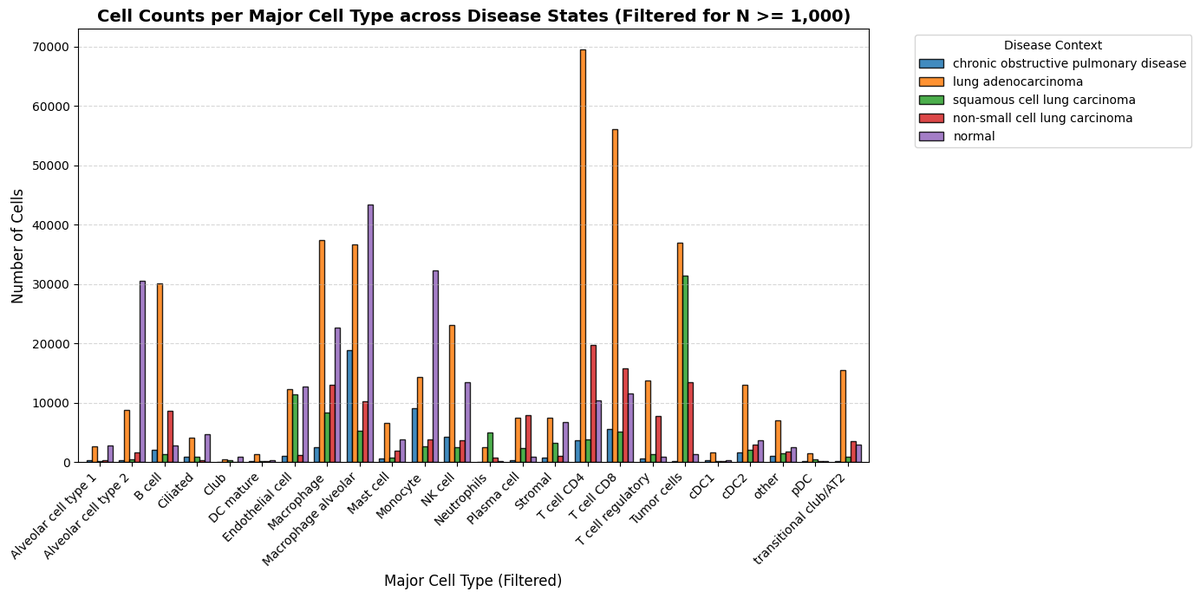

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate overall counts per major cell type
cell_type_totals = adata_backed.obs['cell_type_major'].value_counts()

# 2. Identify and filter out labels with less than 1,000 counts
keep_labels = cell_type_totals[cell_type_totals >= 1000].index

print("--- Filtering Summary ---")
print(f"Original unique cell types: {len(cell_type_totals)}")
print(f"Cell types with >= 1,000 cells: {len(keep_labels)}")
print("\nDropped cell types (fewer than 1,000 cells):")
print(cell_type_totals[cell_type_totals < 1000])

# 3. Filter the dataframe and generate the cross-tabulation table
filtered_obs = adata_backed.obs[adata_backed.obs['cell_type_major'].isin(keep_labels)]
ct_disease_counts = pd.crosstab(
    filtered_obs['cell_type_major'], 
    filtered_obs['disease']
)

# 4. Generate the Grouped Bar Plot
plt.figure(figsize=(14, 8))

# Using a standard linear scale since tiny low-abundance cell types are now removed,
# but feel free to switch to log scale (yscale('log')) if individual ranges are still highly skewed.
ct_disease_counts.plot(kind='bar', figsize=(14, 7), width=0.8, edgecolor='black', alpha=0.85)

plt.title("Cell Counts per Major Cell Type across Disease States (Filtered for N >= 1,000)", fontsize=14, fontweight='bold')
plt.xlabel("Major Cell Type (Filtered)", fontsize=12)
plt.ylabel("Number of Cells", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Disease Context", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. Show final balanced numbers layout matrix
print("\n--- Filtered Count Matrix ---")
print(ct_disease_counts)

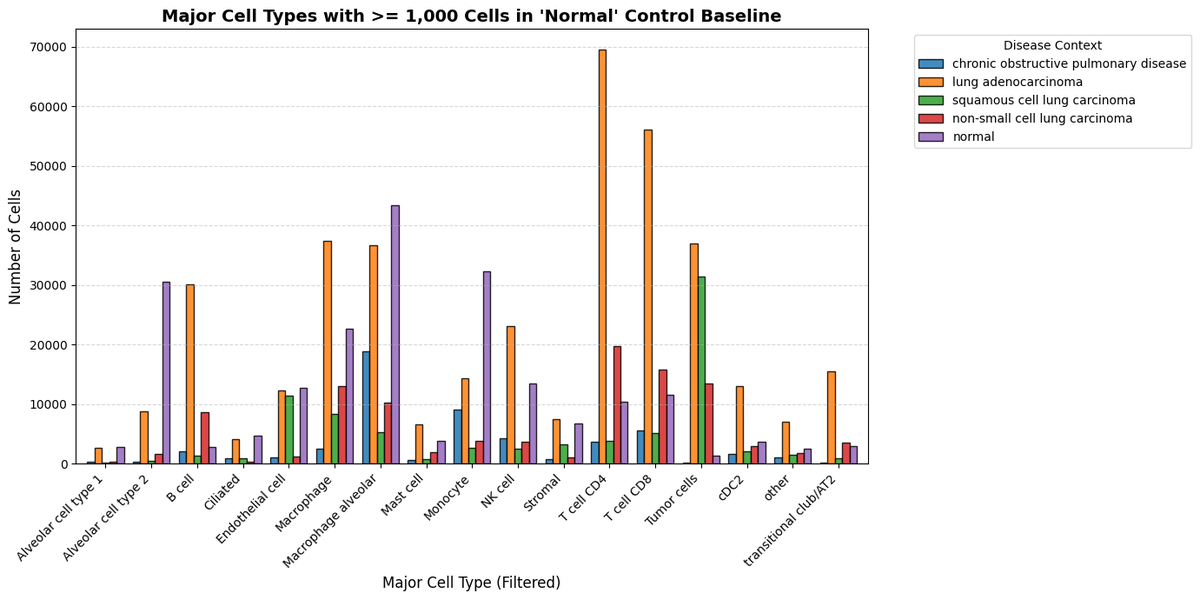

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compute the raw cross-tabulation matrix first (Cell Type vs Disease)
ct_disease_counts = pd.crosstab(
    adata_backed.obs['cell_type_major'], 
    adata_backed.obs['disease']
)

# 2. Identify cell types that have 1,000 or more counts strictly in the 'normal' column
# (This filters out cell types under-represented in your healthy control group)
if 'normal' in ct_disease_counts.columns:
    keep_labels = ct_disease_counts[ct_disease_counts['normal'] >= 1000].index
    
    print("--- Filtering Summary (N >= 1,000 in 'normal' state) ---")
    print(f"Original cell types: {len(ct_disease_counts)}")
    print(f"Cell types kept: {len(keep_labels)}")
    
    dropped_labels = ct_disease_counts[ct_disease_counts['normal'] < 1000].index
    print("\nDropped cell types (Fewer than 1,000 cells in 'normal'):")
    print(ct_disease_counts.loc[dropped_labels, ['normal']])
else:
    raise KeyError("The column 'normal' was not found in the disease classifications. Please verify label names.")

# 3. Filter the cross-tabulation matrix for plotting
filtered_counts = ct_disease_counts.loc[keep_labels]

# 4. Generate the Grouped Bar Plot
plt.figure(figsize=(14, 8))
filtered_counts.plot(kind='bar', figsize=(14, 7), width=0.8, edgecolor='black', alpha=0.85)

plt.title("Major Cell Types with >= 1,000 Cells in 'Normal' Control Baseline", fontsize=14, fontweight='bold')
plt.xlabel("Major Cell Type (Filtered)", fontsize=12)
plt.ylabel("Number of Cells", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Disease Context", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. Display the final filtered matrix to review data balancing
print("\n--- Filtered Count Matrix ---")
print(filtered_counts)

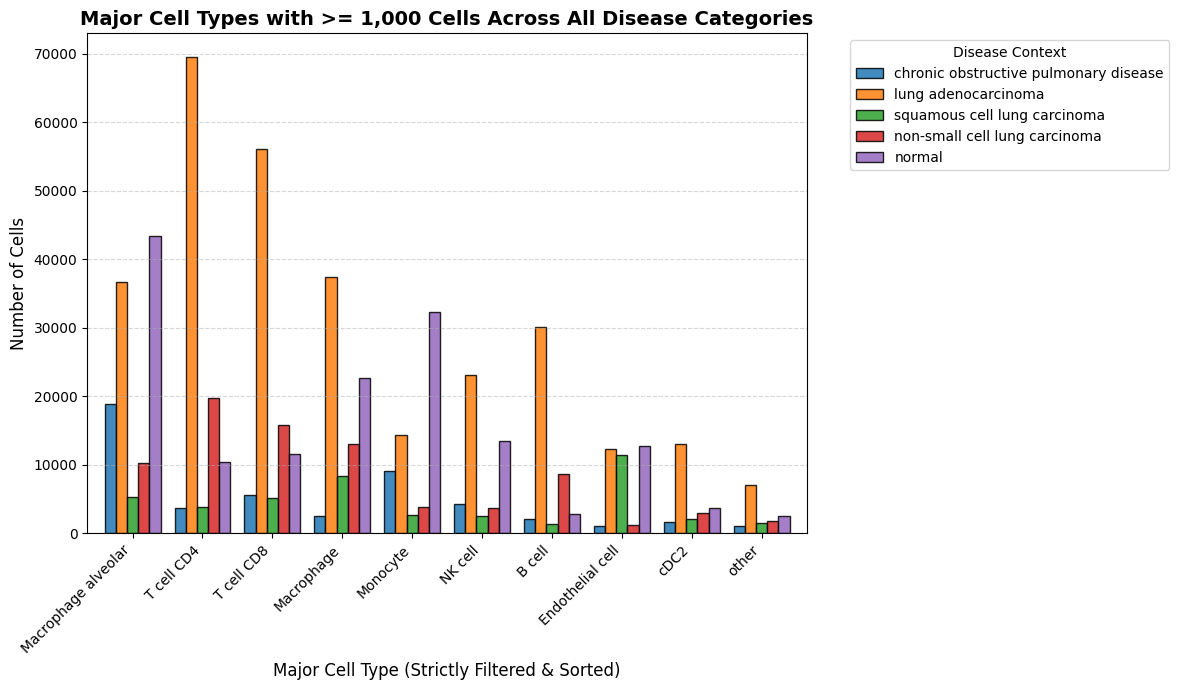

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compute the full cross-tabulation matrix (Cell Type vs Disease)
ct_disease_counts = pd.crosstab(
    adata_backed.obs['cell_type_major'], 
    adata_backed.obs['disease']
)

# 2. Filter for cell types where EVERY disease category has >= 1,000 cells
# .all(axis=1) ensures that the condition is met across all columns for each row
keep_labels = ct_disease_counts[(ct_disease_counts >= 1000).all(axis=1)].index

print("--- Filtering Summary (N >= 1,000 in ALL disease categories) ---")
print(f"Original unique cell types: {len(ct_disease_counts)}")
print(f"Cell types meeting the strict cross-category threshold: {len(keep_labels)}")

# 3. Extract the matching rows and sort them by total abundance for the bar chart
filtered_counts = ct_disease_counts.loc[keep_labels].copy()
filtered_counts['Total_Cells'] = filtered_counts.sum(axis=1)
filtered_counts = filtered_counts.sort_values(by='Total_Cells', ascending=False)
filtered_counts = filtered_counts.drop(columns=['Total_Cells'])

# 4. Generate and save the Grouped Bar Plot
# (Note: following optimal plotting guidelines, we save directly to disk)
ax = filtered_counts.plot(kind='bar', figsize=(12, 7), width=0.8, edgecolor='black', alpha=0.85)

plt.title("Major Cell Types with >= 1,000 Cells Across All Disease Categories", fontsize=14, fontweight='bold')
plt.xlabel("Major Cell Type (Strictly Filtered & Sorted)", fontsize=12)
plt.ylabel("Number of Cells", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Disease Context", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout and save the visualization safely without truncating labels
plt.tight_layout()
plt.savefig("cell_type_vs_disease_all_above_1000.png", dpi=100, bbox_inches='tight')
print("\nPlot successfully saved as 'cell_type_vs_disease_all_above_1000.png'.")

# 5. Display the final strict matrix to review your balanced lineages
print("\n--- Final Filtered Count Matrix ---")
print(filtered_counts)

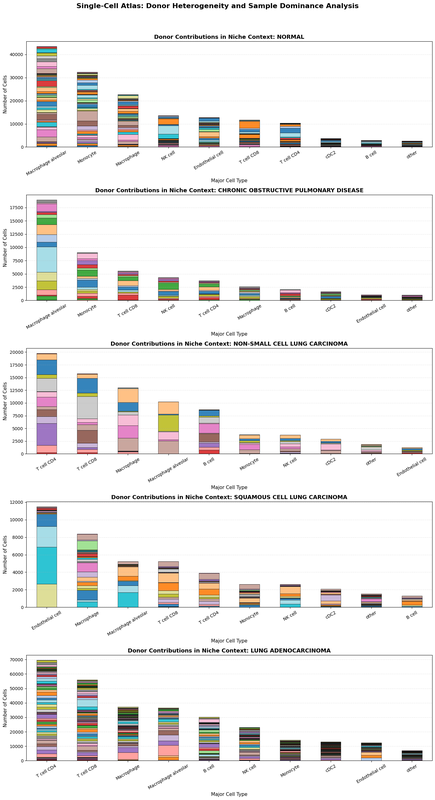

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PRE-FILTER LABELS USING YOUR CRITERIA
# =====================================================================
# Compute the simple crosstab first to evaluate your threshold criteria
ct_disease_counts = pd.crosstab(
    adata_backed.obs['cell_type_major'], 
    adata_backed.obs['disease']
)
# Retain cell types with >= 1000 cells across all categories
keep_labels = ct_disease_counts[(ct_disease_counts >= 1000).all(axis=1)].index

# Filter the raw observations dataframe to only keep robust lineages
filtered_obs = adata_backed.obs[adata_backed.obs['cell_type_major'].isin(keep_labels)].copy()

# =====================================================================
# 2. COMPUTE THREE-WAY CROSSTABULATION (Cell Type x Disease x Donor)
# =====================================================================
# This maps how many cells every individual patient contributes to each subgroup
three_way_counts = pd.crosstab(
    index=[filtered_obs['cell_type_major'], filtered_obs['disease']],
    columns=filtered_obs['donor_id']
)

# Get list of unique diseases to loop through for plotting
diseases = filtered_obs['disease'].unique()

# =====================================================================
# 3. GENERATE THE STACKED BAR PLOTS
# =====================================================================
# Setup separate vertically stacked subplots for each disease category
fig, axes = plt.subplots(len(diseases), 1, figsize=(14, 5 * len(diseases)), sharex=False)
if len(diseases) == 1:
    axes = [axes]

# Assign a diverse palette to handle multiple donors visually
color_palette = sns.color_palette("tab20", n_colors=filtered_obs['donor_id'].nunique())

for i, disease in enumerate(diseases):
    # Isolate data specific to the current disease context
    # This selects the rows corresponding to the multi-index slice
    disease_data = three_way_counts.xs(disease, level='disease')
    
    # Sort by total cells to preserve a clean descending visualization layout
    disease_data = disease_data.loc[disease_data.sum(axis=1).sort_values(ascending=False).index]
    
    # Plot the stacked bar chart directly on the assigned subplot axis
    disease_data.plot(
        kind='bar', 
        stacked=True, 
        ax=axes[i], 
        color=color_palette, 
        edgecolor='black', 
        linewidth=0.5,
        alpha=0.9
    )
    
    axes[i].set_title(f"Donor Contributions in Niche Context: {disease.upper()}", fontsize=13, fontweight='bold')
    axes[i].set_ylabel("Number of Cells", fontsize=11)
    axes[i].set_xlabel("Major Cell Type", fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    
    # Turn off individual legends as they will overflow with dozens of donor names
    axes[i].get_legend().remove()

# Add a single explanatory helper label or select top donors if legend tracking is required
plt.suptitle("Single-Cell Atlas: Donor Heterogeneity and Sample Dominance Analysis", fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()

# Save the diagnostic image out to disk
plt.savefig("donor_leakage_risk_stacked_bars.png", dpi=100, bbox_inches='tight')
plt.show()

print("\nDiagnostic plot successfully saved as 'donor_leakage_risk_stacked_bars.png'.")

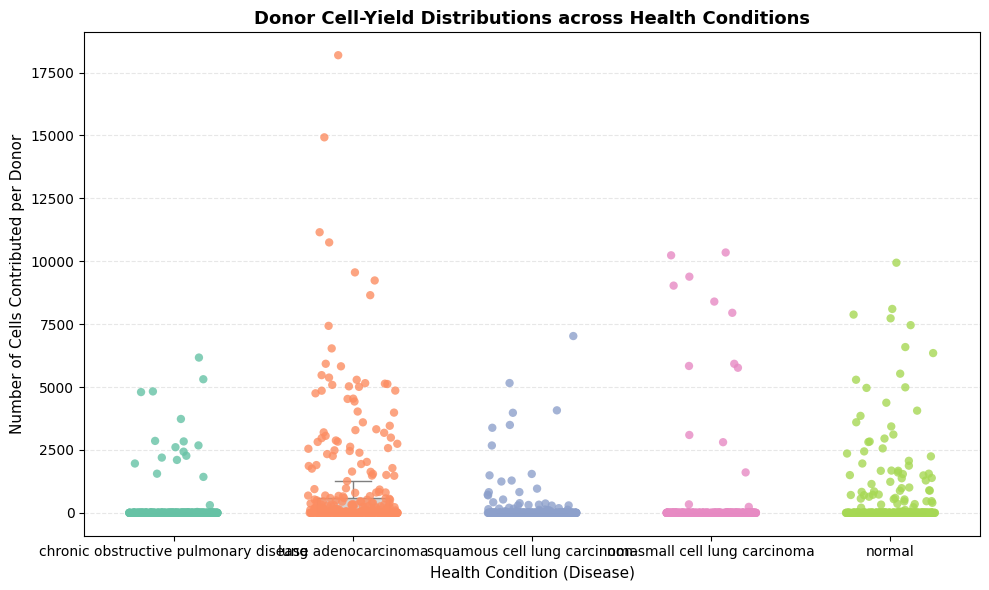

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute cell counts contributed per unique donor within each health condition
# This works with your existing `filtered_obs` DataFrame from your previous filter step.
donor_disease_counts = filtered_obs.groupby(['disease', 'donor_id']).size().reset_index(name='cell_count')

# 2. Plotting a clean Boxplot + Individual Donor Strips
plt.figure(figsize=(10, 6))

# Boxplot reveals the group quartiles and overall spreading behavior
sns.boxplot(
    data=donor_disease_counts, 
    x='disease', 
    y='cell_count', 
    color='lightgray', 
    width=0.4, 
    fliersize=0
)

# Stripplot overlays every single actual patient as an explicit dot
sns.stripplot(
    data=donor_disease_counts, 
    x='disease', 
    y='cell_count', 
    size=6, 
    jitter=0.25, 
    palette='Set2', 
    hue='disease',
    alpha=0.8,
    legend=False
)

plt.title("Donor Cell-Yield Distributions across Health Conditions", fontsize=13, fontweight='bold')
plt.xlabel("Health Condition (Disease)", fontsize=11)
plt.ylabel("Number of Cells Contributed per Donor", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Save the diagnostic image out to disk cleanly
plt.tight_layout()
plt.savefig("donor_leakage_simple_boxplot.png", dpi=100, bbox_inches='tight')
plt.show()

print("\n--- Diagnostic Check Summary ---")
# Quickly print out the maximum outlier info to check who dominates
max_contributors = donor_disease_counts.sort_values(by='cell_count', ascending=False).head(3)
print("Top 3 individual patient footprints in the dataset:")
print(max_contributors.to_string(index=False))

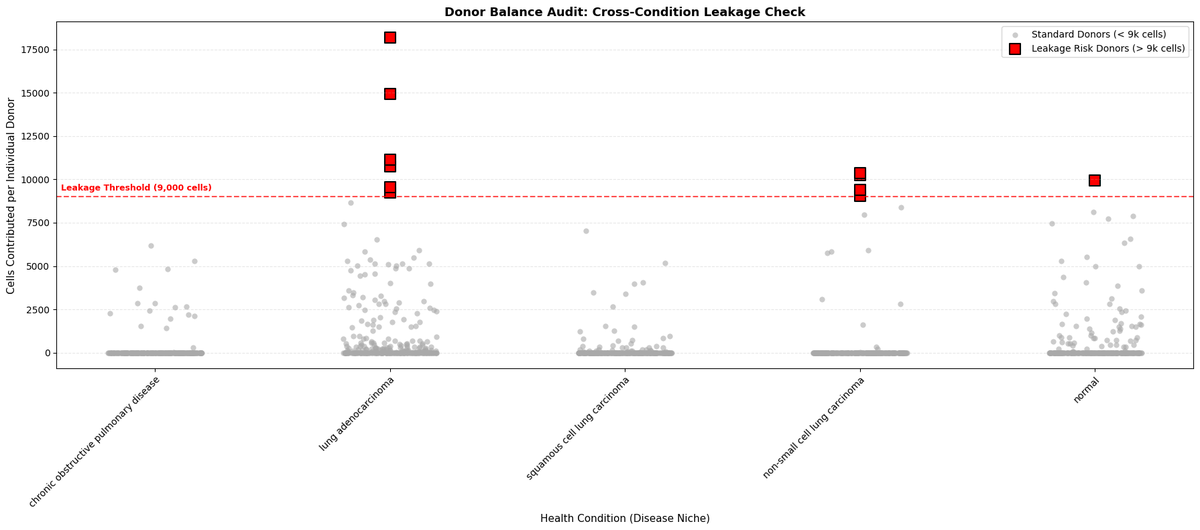

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. IDENTIFY ROBUST CELL TYPES ACCROSS ALL CATEGORIES (N >= 1000)
# =====================================================================
print("Analyzing cross-tabulation thresholds across all health conditions...")

# Compute the raw cross-tabulation matrix (Cell Type vs Disease)
ct_disease_counts = pd.crosstab(
    adata_backed.obs['cell_type_major'], 
    adata_backed.obs['disease']
)

# Identify cell types where EVERY single disease category has >= 1,000 cells
keep_labels = ct_disease_counts[(ct_disease_counts >= 1000).all(axis=1)].index

print(f" -> Total unique cell types evaluated: {len(ct_disease_counts)}")
print(f" -> Cell types meeting the strict cross-category threshold: {len(keep_labels)}")

# Isolate the robust lineages into your operational DataFrame slice
filtered_obs = adata_backed.obs[adata_backed.obs['cell_type_major'].isin(keep_labels)].copy()

# =====================================================================
# 2. RUN DONOR LEAKAGE METRIC CALCULATIONS
# =====================================================================
# Compute cell yields per unique donor within each health condition
donor_counts = filtered_obs.groupby(['disease', 'donor_id']).size().reset_index(name='cell_count')

# Flag donors contributing more than 9,000 cells to a single pool
LEAKAGE_THRESHOLD = 9000
donor_counts['Is_Outlier'] = donor_counts['cell_count'] > LEAKAGE_THRESHOLD

# Segregate the standard patient pool from high-risk outlier candidates
normal_donors = donor_counts[~donor_counts['Is_Outlier']]
outlier_donors = donor_counts[donor_counts['Is_Outlier']]

# =====================================================================
# 3. GENERATE DIAGNOSTIC DISTRIBUTION PLOT WITH ANCHORED LABELS
# =====================================================================
plt.figure(figsize=(18, 8))

# Background Layer: Standard donor footprints plotted as gray jittered points
sns.stripplot(
    data=normal_donors,
    x='disease',
    y='cell_count',
    size=6,
    jitter=0.2,
    color='darkgray',
    alpha=0.6,
    label='Standard Donors (< 9k cells)'
)

# Foreground Layer: Leakage risk outliers highlighted as prominent red squares
if not outlier_donors.empty:
    sns.scatterplot(
        data=outlier_donors,
        x='disease',
        y='cell_count',
        s=120,
        color='red',
        marker='s',
        edgecolor='black',
        linewidth=1.5,
        label='Leakage Risk Donors (> 9k cells)'
    )

# Draw the red threshold evaluation reference line
plt.axhline(y=LEAKAGE_THRESHOLD, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.text(
    x=-0.4, 
    y=LEAKAGE_THRESHOLD + (donor_counts['cell_count'].max() * 0.02), 
    s=f"Leakage Threshold ({LEAKAGE_THRESHOLD:,} cells)", 
    color='red', 
    fontweight='bold', 
    fontsize=9
)

# Apply formatting properties
plt.title("Donor Balance Audit: Cross-Condition Leakage Check", fontsize=13, fontweight='bold')
plt.xlabel("Health Condition (Disease Niche)", fontsize=11)
plt.ylabel("Cells Contributed per Individual Donor", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# -----------------------------------------------------------------
# FIX OVERLAPPING HORIZONTAL LABELS HERE
# -----------------------------------------------------------------
# Rotate 45 degrees, shift text anchor to the right, and fix alignment mode
plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=10)

# De-duplicate legend entries from multi-layered Seaborn assets
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')

# Tighten frame geometry so long axis names are not cropped out at the bottom
plt.tight_layout()

# Save the polished diagnostic visualization safely to your workspace folder
plt.savefig("donor_leakage_check_fixed_labels.png", dpi=100, bbox_inches='tight')
plt.show()

print("\n[SUCCESS] Polished plot successfully saved as 'donor_leakage_check_fixed_labels.png'")

# =====================================================================
# 4. EXPLICITLY PRINT THE MACHINE LEARNING RISK REGISTRY
# =====================================================================
print("\n" + "="*50)
print("CRITICAL MACHINE LEARNING RISK REGISTER")
print("="*50)

if not outlier_donors.empty:
    sorted_outliers = outlier_donors.sort_values(by='cell_count', ascending=False)
    print(sorted_outliers[['disease', 'donor_id', 'cell_count']].to_string(index=False))
    print("\n⚠️ STRATEGIC INSTRUCTION FOR FINETUNING MODEL:")
    print("The specific patient donor IDs listed above contribute disproportionate data volume.")
    print("When splitting into Train/Validation/Test data subsets, you MUST use group-level splitting")
    print("on 'donor_id' (e.g., scikit-learn GroupShuffleSplit). If these specific patients leak")
    print("across splits, your cross-entropy loss weights will overfit to individual patient noise.")
else:
    print("Excellent! No individual donor profiles exceed the 9,000 cell contribution limit.")
print("="*50)